In [1]:
import os
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

API_URL = os.getenv("LITELLM_URL", "http://localhost:8088/v1/chat/completions")
API_KEY = os.getenv("LITELLM_MASTER_KEY", "sk-fase0-local")
MODEL = os.getenv("LITELLM_MODEL", "local-chat")
THINK = os.getenv("LITELLM_THINK", "false").lower() == "true"

def measure_request(prompt):
    payload = {
       "model": MODEL,
       "messages": [{"role": "user", "content": prompt}],
       "max_tokens": 40,
       "think": THINK,
    }   
    
    start_time = time.time()
    # Usamos requests.post para ejecutar de verdad la petición
    response = requests.post(API_URL, json=payload, headers={
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    })
    end_time = time.time()
    
    latency = end_time - start_time
    
    # Extraemos la respuesta y el estado de la caché
    res_json = response.json()
    answer = res_json['choices'][0]['message']['content']
    is_cache = response.headers.get("x-litellm-cache-hit") == "True"
    
    return latency, is_cache, answer

In [2]:
prompts = ["¿Qué es la computación distribuida?", "Explica el teorema de CAP"]
results = []

for p in prompts:
    print(f"Probando: {p}")
    # 1. Primera vez: CACHE MISS (Inferencia real)
    lat, cached, answer = measure_request(p)
    results.append({"prompt": p, "latencia": lat, "tipo": "Inferencia (Ollama)"})
    print(f"Respuesta: {answer[:100]}...")

    # 2. Segunda vez: CACHE HIT (Redis)
    lat, cached, answer = measure_request(p)
    results.append({"prompt": p, "latencia": lat, "tipo": "Caché (Redis)"})
    print(f"Respuesta: {answer[:100]}...")

df = pd.DataFrame(results)
display(df)

Probando: ¿Qué es la computación distribuida?
Respuesta: La **computación distribuida** es un tipo de computación que utiliza múltiples ordenadores y redes d...
Respuesta: La **computación distribuida** es un tipo de computación que utiliza múltiples ordenadores y redes d...
Probando: Explica el teorema de CAP
Respuesta: El **Teorema de CAP (Content-Aware Privacy Preservation)** es un algoritmo de privacidad basado en i...
Respuesta: El **Teorema de CAP (Content-Aware Privacy Preservation)** es un algoritmo de privacidad basado en i...


,prompt,latencia,tipo
0,¿Qué es la computación distribuida?,0.009109,Inferencia (Ollama)
1,¿Qué es la computación distribuida?,0.005570,Caché (Redis)
2,Explica el teorema de CAP,0.006006,Inferencia (Ollama)
3,Explica el teorema de CAP,0.005806,Caché (Redis)


<Figure size 1000x600 with 0 Axes>

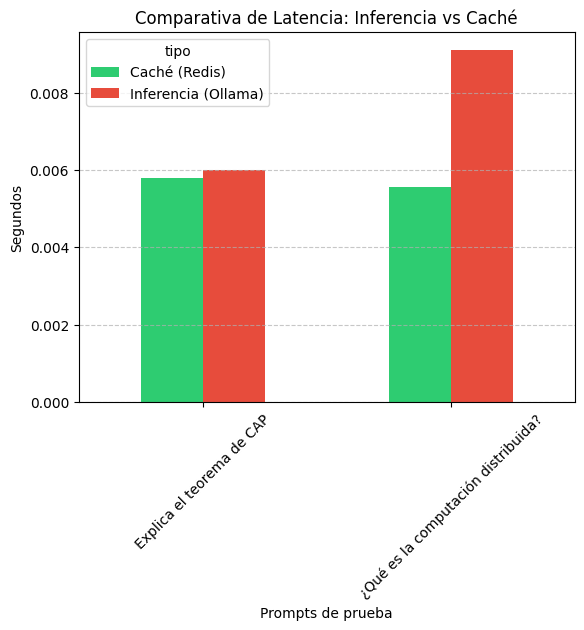

In [3]:
plt.figure(figsize=(10, 6))
pivot_df = df.pivot(index='prompt', columns='tipo', values='latencia')

pivot_df.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Comparativa de Latencia: Inferencia vs Caché')
plt.ylabel('Segundos')
plt.xlabel('Prompts de prueba')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [4]:
print("=== PRUEBAS DE CACHE SEMÁNTICO ===\n")

semantic_prompts = [
    "¿Qué es la computación distribuida?",
    "Explícame qué es la computación distribuida",
    "¿En qué consiste la computación distribuida?",
    "Define computación distribuida"
]

semantic_results = []

for i, p in enumerate(semantic_prompts):
    print(f"{i+1}. Prompt: {p}")
    lat, cached, answer = measure_request(p)
    tipo = "Caché (Redis)" if lat < 1 else "Inferencia (Ollama)"
    semantic_results.append({"prompt": p, "latencia": lat, "tipo": tipo})
    print(f"   Latencia: {lat:.2f}s - {tipo}")
    print(f"   Respuesta: {answer[:80]}... \n")

df_semantic = pd.DataFrame(semantic_results)
display(df_semantic)

print("--- RESUMEN ---")
print(f"Original: {semantic_results[0]['latencia']:.2f}s")
print(f"Variación léxica: {semantic_results[1]['latencia']:.2f}s - {'Cache semántico detectar' if semantic_results[1]['latencia'] < 1 else 'Cache semántico NO detectó'}")
print(f"Variación sinónimos: {semantic_results[2]['latencia']:.2f}s - {'✓ Cache semántico funcionó' if semantic_results[2]['latencia'] < 1 else '✗ No funcionó'}")
print(f"Reformulación: {semantic_results[3]['latencia']:.2f}s - {'✓ Cache semántico funcionó' if semantic_results[3]['latencia'] < 1 else '✗ No funcionó'}")

=== PRUEBAS DE CACHE SEMÁNTICO ===

1. Prompt: ¿Qué es la computación distribuida?
   Latencia: 0.01s - Caché (Redis)
   Respuesta: La **computación distribuida** es un tipo de computación que utiliza múltiples o... 

2. Prompt: Explícame qué es la computación distribuida
   Latencia: 0.01s - Caché (Redis)
   Respuesta: ... 

3. Prompt: ¿En qué consiste la computación distribuida?
   Latencia: 6.71s - Inferencia (Ollama)
   Respuesta: La **computación distribuida** es un paradigma de computación que implica el pro... 

4. Prompt: Define computación distribuida
   Latencia: 7.45s - Inferencia (Ollama)
   Respuesta: **Computación distribuida** es una forma de computación donde un sistema se divi... 



,prompt,latencia,tipo
0,¿Qué es la computación distribuida?,0.006624,Caché (Redis)
1,Explícame qué es la computación distribuida,0.005667,Caché (Redis)
2,¿En qué consiste la computación distribuida?,6.714407,Inferencia (Ollama)
3,Define computación distribuida,7.452628,Inferencia (Ollama)


--- RESUMEN ---
Original: 0.01s
Variación léxica: 0.01s - Cache semántico detectar
Variación sinónimos: 6.71s - ✗ No funcionó
Reformulación: 7.45s - ✗ No funcionó
